In [ ]:
%run quant_run.py

[GILD] 심층 분석 및 그래프 생성 중...


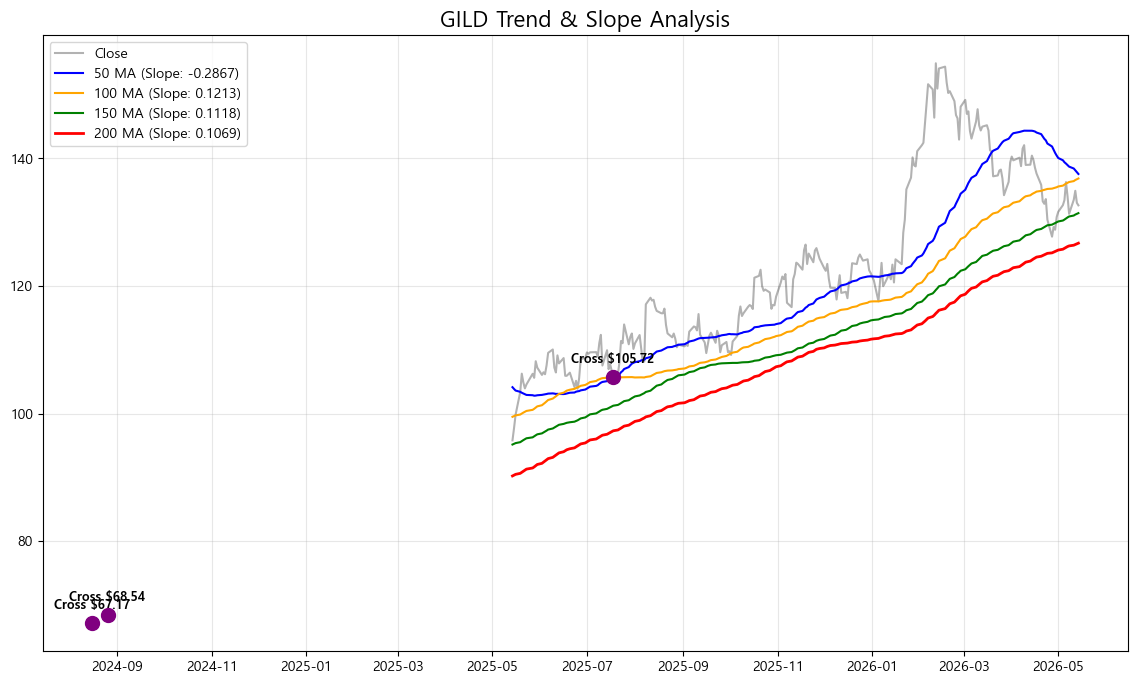


📊 [GILD] 현재 시점 기울기 분석 (미분값)
 -  50일선 기울기:  -0.2867 (하락세 ↘️)
 - 100일선 기울기:   0.1213 (상승세 ↗️)
 - 150일선 기울기:   0.1118 (상승세 ↗️)
 - 200일선 기울기:   0.1069 (상승세 ↗️)

📍 최근 주요 이평선 교점 가격
 - 50-100 교점: $105.72 (2025-07-18)
 - 50-150 교점: $67.17 (2024-08-16)
 - 50-200 교점: $68.54 (2024-08-26)


In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def analyze_stock(ticker):
    print(f"[{ticker}] 심층 분석 및 그래프 생성 중...")
    
    try:
        # 1. 데이터 수집 (충분한 계산을 위해 2년치)
        stock = yf.Ticker(ticker)
        df = stock.history(period="2y")
        if df.empty: return

        # 2. 이동평균선 계산 (50, 100, 150, 200)
        windows = [50, 100, 150, 200]
        for w in windows:
            df[f'MA{w}'] = df['Close'].rolling(window=w).mean()

        # 3. 마지막 지점 기울기(미분) 계산
        # 최근 3일간의 데이터를 선형 회귀하여 기울기를 구합니다.
        slopes = {}
        for w in windows:
            y = df[f'MA{w}'].tail(3).values
            if not np.isnan(y).any():
                x = np.array([0, 1, 2])
                slope = np.polyfit(x, y, 1)[0] # 1차식 기울기 추출
                slopes[f'MA{w}'] = slope

        # 4. 최근 교점(Cross) 찾기
        # 50일선이 다른 선들과 만나는 최근 지점의 가격을 찾습니다.
        cross_points = []
        for other in [100, 150, 200]:
            # 두 선의 차이의 부호가 바뀌는 지점이 교점
            diff = df['MA50'] - df[f'MA{other}']
            crossings = df.loc[diff.shift(1) * diff < 0]
            if not crossings.empty:
                last_cross = crossings.tail(1)
                cross_points.append({
                    'target': f'50-{other}',
                    'date': last_cross.index[0].strftime('%Y-%m-%d'),
                    'price': last_cross['MA50'].values[0]
                })

        # 5. 그래프 시각화
        df_plot = df.tail(252)
        plt.figure(figsize=(14, 8))
        plt.plot(df_plot.index, df_plot['Close'], label='Close', color='black', alpha=0.3)
        
        colors = {50: 'blue', 100: 'orange', 150: 'green', 200: 'red'}
        for w in windows:
            plt.plot(df_plot.index, df_plot[f'MA{w}'], label=f'{w} MA (Slope: {slopes.get(f"MA{w}", 0):.4f})', 
                     color=colors[w], linewidth=2 if w==200 else 1.5)

        # 교점 표시
        for cp in cross_points:
            plt.scatter(pd.to_datetime(cp['date']), cp['price'], color='purple', s=100, zorder=5)
            plt.annotate(f"Cross ${cp['price']:.2f}", (pd.to_datetime(cp['date']), cp['price']), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

        plt.title(f"{ticker} Trend & Slope Analysis", fontsize=16)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # 6. 수치 결과 출력
        print("\n" + "="*50)
        print(f"📊 [{ticker}] 현재 시점 기울기 분석 (미분값)")
        for w in windows:
            s = slopes.get(f'MA{w}', 0)
            status = "상승세 ↗️" if s > 0 else "하락세 ↘️"
            print(f" - {w:3}일선 기울기: {s:8.4f} ({status})")
        
        print("\n📍 최근 주요 이평선 교점 가격")
        for cp in cross_points:
            print(f" - {cp['target']} 교점: ${cp['price']:.2f} ({cp['date']})")
        print("="*50)

    except Exception as e:
        print(f"에러 발생: {e}")

# 실행
target = input("조회할 종목 티커 입력: ").upper()
analyze_stock(target)